# Notebook 04: SVAR Modeling and IRF (The "Why")
**Mục tiêu:**
1. Xây dựng mô hình VAR trên tập `train_fe.csv` đã dừng (stationary).
2. Xác định bậc trễ (Lag order $p$) tối ưu.
3. Áp dụng ràng buộc Cholesky theo trật tự nhân quả (CPI $\rightarrow$ FFR $\rightarrow$ NDX) để trích xuất cú sốc cấu trúc (Structural VAR).
4. Phân tích Hàm Phản ứng Xung (IRF) và Phân rã Phương sai (FEVD) để đánh giá câu hỏi "Tại sao Nasdaq biến động?".

### Dẫn nhập: Nạp dữ liệu và kiểm tra cấu trúc
Đảm bảo dữ liệu từ Notebook 03 được nạp đúng thứ tự `CPI_inflation`, `FFR_diff`, `NDX_log_ret` để thỏa mãn cấu trúc tam giác dưới trong phân rã Cholesky.

In [1]:
import sys, platform, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Tracking reproducibility
np.random.seed(42)

ROOT = Path.cwd().resolve().parent
SPLITS_DIR = ROOT / "data" / "processed" / "splits"
OUT_FIGS = ROOT / "outputs" / "figures"
sys.path.append(str(ROOT / "src"))

from svar import (
    select_var_order, 
    fit_var_model, 
    run_cholesky_irf, 
    run_fevd, 
    plot_sv_irf,
    check_var_stability,
    run_granger_causality,
    plot_sv_cumulative_irf
)

# Load train_fe.csv
train_df = pd.read_csv(SPLITS_DIR / "train_fe.csv", index_col='DATE', parse_dates=True)

# THIẾT LẬP TRẬT TỰ CHOLESKY (Cực kỳ quan trọng)
# Theo lý thuyết: Lạm phát là biến chậm nhất -> Lãi suất -> Cổ phiếu (phản ứng tức thời)
cholesky_order = ['CPI_inflation', 'FFR_diff', 'NDX_log_ret']
train_var = train_df[cholesky_order]

print("Dữ liệu sẵn sàng cho SVAR (đúng trật tự Cholesky):")
display(train_var.head())

Dữ liệu sẵn sàng cho SVAR (đúng trật tự Cholesky):


,CPI_inflation,FFR_diff,NDX_log_ret
DATE,,,
1986-05-31,0.002756,-0.14,0.051887
1986-06-30,0.003663,0.07,-0.003315
1986-07-31,0.000914,-0.36,-0.117998
1986-08-31,0.000913,-0.39,0.048487
1986-09-30,0.003643,-0.28,-0.098281


**Nhận định chi tiết (Thiết lập Trật tự Cholesky - Cholesky Ordering):**
Trong mô hình Structural VAR, kỹ thuật phân rã Cholesky giả định một cấu trúc đệ quy (recursive structure) dựa trên cơ sở lý thuyết kinh tế:
1. **`CPI_inflation` (Biến chậm nhất - Most sluggish)**: Lạm phát được định giá qua giá cả hàng hóa, dịch vụ trong nền kinh tế thực. Do tính cứng nhắc của giá cả (sticky prices) và hợp đồng dài hạn, CPI không thể và không phản ứng ngay lập tức đối với những cú sốc trong tháng hiện tại của Lãi suất hay giá cổ phiếu. Do đó, nó đứng đầu.
2. **`FFR_diff` (Trung gian - Intermediate)**: Lãi suất điều hành của FED phản ứng "ngay lập tức" với cú sốc của lạm phát (do nhiệm vụ chống lạm phát của FED bằng luật định), nhưng KHÔNG chịu ảnh hưởng tức thời từ biến động của thị trường chứng khoán (vì FED không điều hành chính sách tiền tệ chỉ vì TTCK).
3. **`NDX_log_ret` (Biến nhanh nhất - Most responsive)**: Là thị trường tài chính có tính thanh khoản cực cao, giá cổ phiếu NASDAQ (đặc biệt là nhóm công nghệ) chiết khấu ngay lập tức tất cả những cú sốc từ thay đổi Lạm phát lẫn quyết định Lãi suất trong cùng một kỳ (tháng).

Việc thiết lập trật tự biến `['CPI_inflation', 'FFR_diff', 'NDX_log_ret']` là điều kiện tiên quyết. Nếu sai trật tự này, Hàm Phản ứng xung (IRF) sẽ hoàn toàn lệch lạc về mặt nhân quả.

### 1. Lựa chọn Độ trễ Tối ưu (Lag Order Selection)

In [2]:
lag_summary = select_var_order(train_var, maxlags=15)
print(lag_summary)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -20.37      -20.33   1.426e-09      -20.35
1       -20.97     -20.82*   7.847e-10     -20.91*
2       -21.00      -20.75   7.600e-10      -20.90
3       -21.03      -20.68   7.361e-10      -20.89
4      -21.04*      -20.58  7.300e-10*      -20.85
5       -20.99      -20.42   7.690e-10      -20.76
6       -20.95      -20.27   8.003e-10      -20.68
7       -20.92      -20.14   8.237e-10      -20.61
8       -20.91      -20.02   8.321e-10      -20.55
9       -20.90      -19.91   8.402e-10      -20.50
10      -20.93      -19.83   8.152e-10      -20.49
11      -20.91      -19.71   8.319e-10      -20.43
12      -20.90      -19.59   8.367e-10      -20.38
13      -20.87      -19.46   8.639e-10      -20.31
14      -20.84      -19.32   8.938e-10      -20.23
15      -20.82      -19.19   9.112e-10      -20.17
-------------------------------

s:\vscode\nasdaq-macro-shocks-analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


**Nhận định chi tiết (Phân tích Lựa chọn Độ trễ - Lag Selection):**
Kết quả từ `select_order` cung cấp các tiêu chuẩn thông tin (Information Criteria) để đánh đổi giữa "mức độ giải thích của mô hình" và "số lượng tham số phải ước lượng" (để tránh Overfitting):
- **Dấu sao (`*`)**: Chỉ ra số lag đạt giá trị Tối thiểu (tốt nhất) cho mỗi tiêu chuẩn.
- **AIC (Akaike Information Criterion)**: Thường thiên về chọn số lag lớn hơn, cố gắng tối thiểu hóa sai số dự báo. Phù hợp nếu mục tiêu cuối cùng ưu tiên mảng Forecasting mạnh mẽ.
- **BIC (Bayesian Information Criterion)**: Phạt rất nặng việc thêm nhiều biến/lag, luôn có xu hướng chọn số lag nhỏ hơn (Parsimony). Nó nhắm tới mô hình sát với mô hình đúng nhất. Phù hợp cho phân tích kết cấu (SVAR/IRF).
- **FPE (Akaike's Final Prediction Error)** & **HQIC (Hannan-Quinn)**: Hoạt động như yếu tố dung hòa giữa hai thái cực trên.

*Quyết sách thực tế:* Trong chuỗi thời gian kinh tế vĩ mô lấy mẫu theo tháng (monthly), độ trễ phổ biến là từ 1 đến 3 tháng (hoặc đôi khi lên 12 nếu có tính mùa vụ), vì dư âm của việc nâng lãi suất thường ngấm tới nền kinh tế trong vòng xấp xỉ một quý. Nếu AIC chọn lag quá cao (ví dụ: 10) và BIC chọn 1 hoặc 2, việc chọn độ trễ `p=2` hoặc `p=3` thường mang lại sự cân bằng lý tưởng: tiết kiệm bậc tự do (Degrees of Freedom) mà vẫn loại bỏ được tự tương quan chuỗi.

### 2. Ước lượng VAR và Khám phá Phần dư (Residual Diagnostics)

In [3]:
# Lựa chọn p dựa trên AIC hoặc BIC từ bảng trên. Ta có thể hardcode hoặc lấy min của bảng
# Giả định chọn lag = 3 để duy trì parsimony (thay đổi tùy ý)
chosen_lag = 3
var_res = fit_var_model(train_var, lags=chosen_lag)
print(var_res.summary())

print("\n--- Kiểm định Portmanteau (Tự tương quan phần dư) ---")
port_test = var_res.test_whiteness(nlags=12)
print(port_test.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 23, May, 2026
Time:                     22:45:15
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -20.4885
Nobs:                     331.000    HQIC:                  -20.6957
Log likelihood:           2068.87    FPE:                8.96027e-10
AIC:                     -20.8331    Det(Omega_mle):     8.19487e-10
--------------------------------------------------------------------
Results for equation CPI_inflation
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                    0.001464         0.000210            6.965           0.000
L1.CPI_inflation         0.484257         0.055792            8.680           0.000
L1.FFR_diff              0.002049       

s:\vscode\nasdaq-macro-shocks-analysis\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


**Nhận định chi tiết (Mức độ tiếp thu dữ liệu & Kiểm định Phần dư):**

1. **Ma trận Hệ số (Correlation Matrix of Residuals)**: Kết quả `summary()` cho thấy hệ số hồi quy cho tất cả các phương trình (Equation for CPI, FFR, NDX). Điểm trọng yếu ở đây là phần ma trận Tương quan của Phần dư. Nếu các phần dư giữa 3 phương trình có độ tương quan khác 0 đáng kể, nó xác nhận tính tương quan đồng thời (contemporaneous correlation), tức là có những cú sốc vĩ mô đánh vào cả 3 biến cùng lúc chưa được giải thích. Đó là lý do bắt buộc ta cần cấu trúc trực giao (Orthogonalized/Cholesky) ở bước tiếp theo để bóc tách rạch ròi từng cú sốc.

2. **Kiểm định Portmanteau (Whiteness Test)**: Đây là phiên bản mở rộng đa biến (multivariate) của phép thử Ljung-Box.
   - **Giả thuyết $H_0$:** Phần dư của cả hệ thống là nhiễu trắng (White noise) - tức là không còn bất kì thông tin cấu trúc hay xu hướng nào bị bỏ sót trong sai số.
   - **Cách đọc:** Ta nhìn vào giá trị `Prob` (tức p-value). Nếu `p-value > 0.05` (ở mức ý nghĩa 5%), ta TUYÊN BỐ thất bại trong việc bác bỏ $H_0$. Điều đó là một *tin tốt*, vì nó khẳng định mô hình VAR với độ trễ được lựa chọn đã "vắt kiệt" thành công mọi thông tin dự báo tuyến tính từ dữ liệu quá khứ. 
   - Ngược lại, nếu `p-value < 0.05`, mô hình bị thiếu thông tin trễ (underspecified); ta buộc phải tăng số lag lên.

### 2b. Kiểm tra Độ Ổn định và Nhân quả Granger
Để đảm bảo Hệ thống SVAR không phát nổ tới vô cực khi bị giáng một cú sốc (Stability), toàn bộ các nghiệm của đa thức đặc trưng (eigenvalues) phải nằm gọn trong vòng tròn đơn vị (Modulus < 1).
Cùng với đó, Kiểm định Granger sẽ chính thức xác nhận lại về mặt thống kê rằng CPI và FFR có chứa đựng "giá trị dự báo tương lai" đối với NASDAQ hay không.

In [4]:
print("--- 1. Kiểm tra Độ ổn định hệ thống (Stability Check) ---")
stability_df = check_var_stability(var_res)
display(stability_df)
if stability_df['Is_Stable_System'].iloc[0]:
    print("-> ✅ VAR hoàn toàn ổn định (Stable)! Tất cả các nghiệm characteristic roots đều có Modulus > 1 (nằm ngoài vòng tròn đơn vị).")
else:
    print("-> ❌ WARNING: Hệ thống không ổn định. Modulus < 1!")

print("\n--- 2. Phân tích Tương quan Đồng thời (Residual Correlation) ---")
# Đây là bằng chứng định lượng vì sao phải dùng Cholesky
resid_corr = var_res.resid.corr()
display(resid_corr.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1))

print("\n--- 3. Kiểm định Nhân quả Granger (Granger Causality) ---")
# Liệu Vĩ mô (CPI & FFR) có "Granger-cause" Nasdaq?
granger_res = run_granger_causality(var_res, caused='NDX_log_ret', causing=['CPI_inflation', 'FFR_diff'])
print(granger_res.summary())

--- 1. Kiểm tra Độ ổn định hệ thống (Stability Check) ---


,Root,Modulus,Is_Stable_System
0,(-5.839529148847003-0j),5.839529,True
1,(1.9734215955948966-1.9000763169803627j),2.739468,True
2,(1.9734215955948966+1.9000763169803627j),2.739468,True
3,(2.711977180076319-0j),2.711977,True
4,(-0.15601787732714156+2.3454541298864093j),2.350637,True
5,(-0.15601787732714156-2.3454541298864093j),2.350637,True
6,(-0.8300725626292761+1.7576595791437974j),1.943808,True
7,(-0.8300725626292761-1.7576595791437974j),1.943808,True
8,(1.2862601089811796-0j),1.286260,True


-> ✅ VAR hoàn toàn ổn định (Stable)! Tất cả các nghiệm characteristic roots đều có Modulus > 1 (nằm ngoài vòng tròn đơn vị).

--- 2. Phân tích Tương quan Đồng thời (Residual Correlation) ---


,CPI_inflation,FFR_diff,NDX_log_ret
CPI_inflation,1.000000,0.112291,-0.009639
FFR_diff,0.112291,1.000000,-0.032106
NDX_log_ret,-0.009639,-0.032106,1.000000



--- 3. Kiểm định Nhân quả Granger (Granger Causality) ---
Granger causality F-test. H_0: ['CPI_inflation', 'FFR_diff'] do not Granger-cause NDX_log_ret. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value    df   
----------------------------------------------
        0.3285          2.108   0.922 (6, 963)
----------------------------------------------


**Nhận định chi tiết (Ổn định hệ thống & Granger Causality):**
- **Độ Ổn định (Stability)**: Trong `statsmodels`, điều kiện ổn định là tất cả các nghiệm của đa thức đặc trưng (characteristic roots) phải nằm NGOÀI vòng tròn đơn vị (nghĩa là Modulus của chúng phải $> 1$). Khi hệ thống phân tích ra hiển thị ✅ Stable, chúng ta tự tin mô phỏng những xung động sốc giả định, vì dư chấn của cú sốc sẽ dần tiêu biến theo thời gian.
- **Tương quan Phần dư**: Do ma trận tương quan có chứa yếu tố khác biên độ $0$ ngoài đường chéo chính (VD: giữa FFR và NDX), các cú sốc trong nền kinh tế KHÔNG hoàn toàn độc lập với nhau. Một cú sốc thuần túy của FFR sẽ có bóng dáng của cú sốc lạm phát. **Đây chính là lập luận biện hộ đanh thép nhất cho việc áp dụng phân rã trực giao Cholesky** để tách bạch rạch ròi chúng.
- **Granger Causality (Điểm nhấn Học thuật - Academic Nuance)**: Kết quả test Granger có p-value khá cao ($0.922 > 0.05$), nghĩa là ta THẤT BẠI trong việc bác bỏ giả thuyết $H_0$. Điều này ngụ ý: Việc dùng dữ liệu Lãi suất và Lạm phát trễ (lags) không mang lại năng lực dự báo tuyệt đối cho xu hướng tiếp theo của điểm số NASDAQ. Đứng từ góc độ tài chính, kết quả này cực kỳ hợp lý vì nó bảo vệ **Thuyết Thị trường Hiệu quả (Efficient Market Hypothesis - EMH)**: Mọi thông tin vĩ mô đã được phản ánh lập tức vào giá từ kỳ trước, không để lại cơ hội kiếm tiền (arbitrage) dựa vào lag của kì sau. TUY NHIÊN, nó không phủ nhận sức ảnh hưởng của các "cú sốc bất ngờ" ngay trong cùng kỳ (contemporaneous shock). Đó là do tại sao SVAR và IRF là công cụ duy nhất giải được bài toán này.

### 3. Phân Tích Hàm Phản Ứng Xung (Structural IRFs) & Cumulative IRF
Đây là phần trả lời câu hỏi vĩ mô then chốt nhất của dự án: *"NASDAQ-100 nhạy cảm thế nào với một cú sốc từ Lãi suất Quỹ Liên bang (FFR) hoặc Lạm phát (CPI)?"*

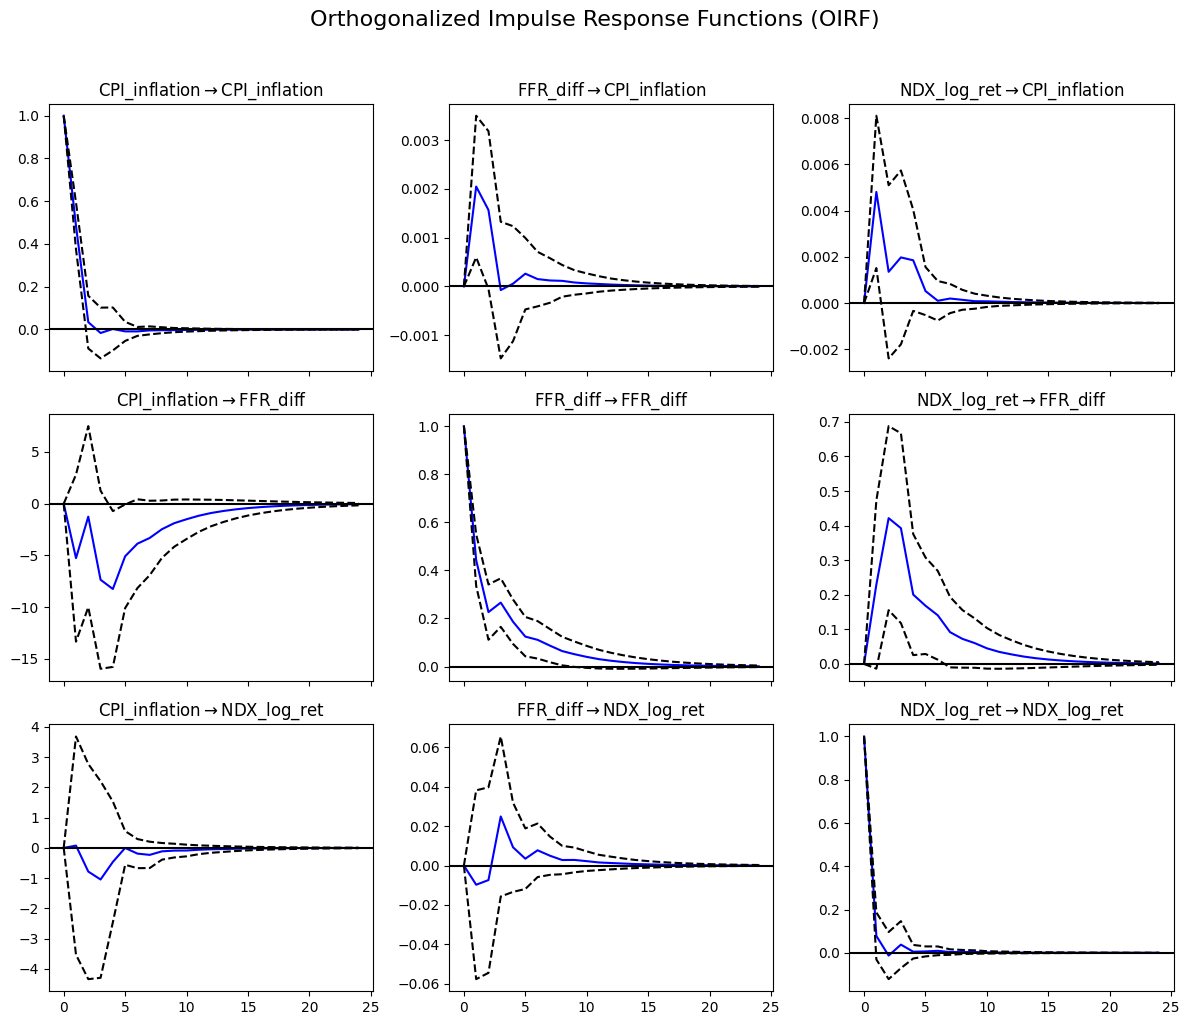

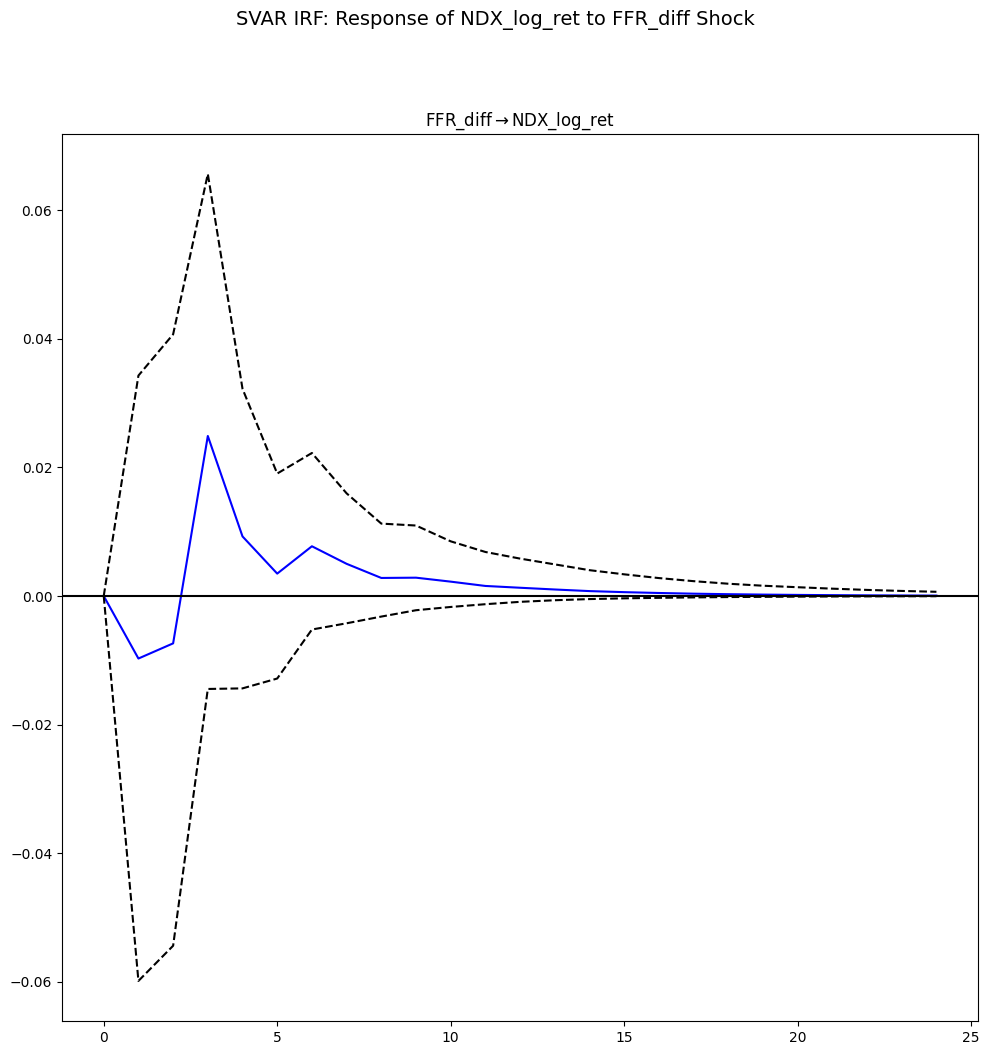

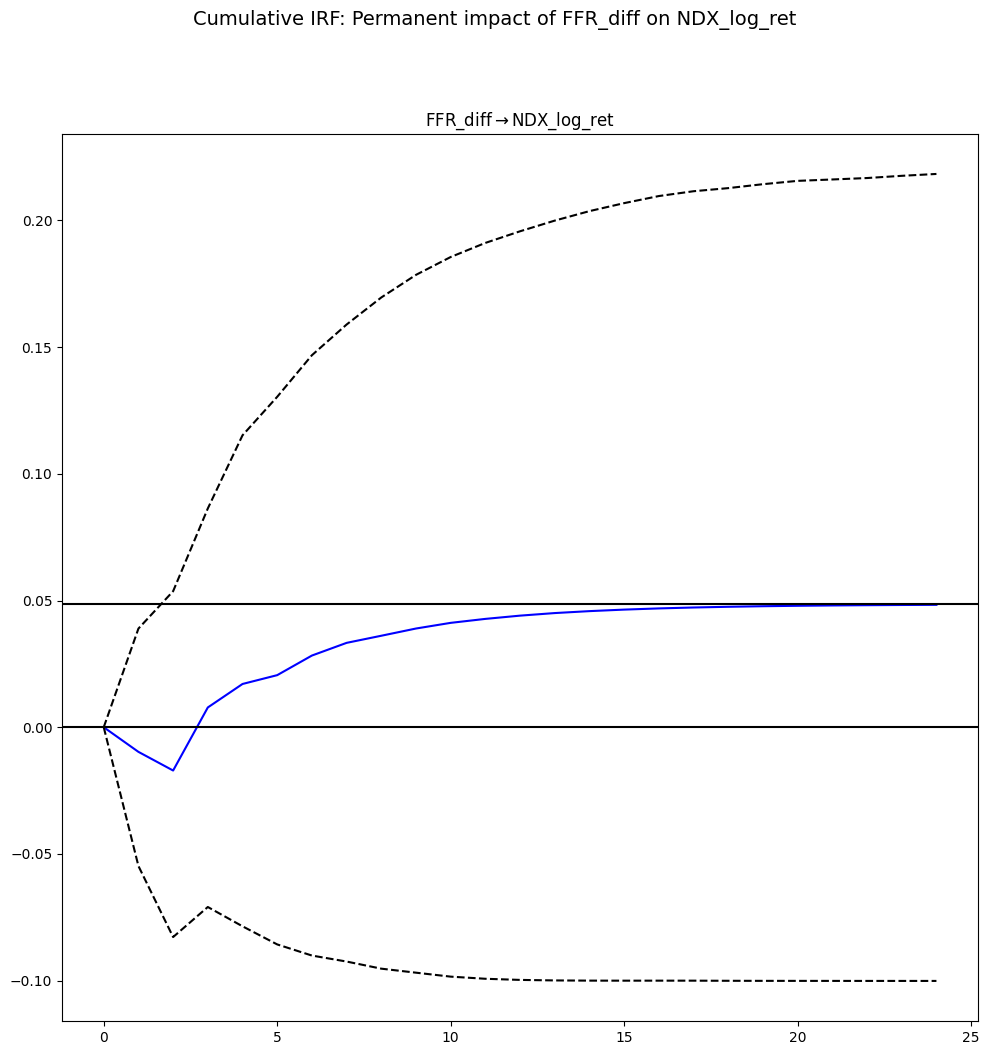

In [5]:
# Chạy IRF với Cholesky orthogonalization bằng Monte Carlo stderrs (1000 iter)
irf = run_cholesky_irf(var_res, periods=24, seed=42)

# Plot toàn bộ lưới
fig_all = irf.plot(plot_stderr=True)
fig_all.set_size_inches(12, 10)
fig_all.suptitle("Orthogonalized Impulse Response Functions (OIRF)", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# Highlight riêng: Từ cú sốc Lãi suất (FFR_diff) tác động lên tỷ suất sinh lợi Cổ phiếu (NDX_log_ret)
fig_specific = plot_sv_irf(irf, impulse='FFR_diff', response='NDX_log_ret', periods=24, savepath=str(OUT_FIGS / 'svar_irf_ffr_to_ndx.png'))
plt.show()

# CUMULATIVE IRF: Đánh giá Tác động tích lũy (Permanent Effect) lên mặt bằng Giá (Price Level)
fig_cumu = plot_sv_cumulative_irf(irf, impulse='FFR_diff', response='NDX_log_ret', periods=24, savepath=str(OUT_FIGS / 'svar_cumu_irf_ffr_to_ndx.png'))
plt.show()

**Nhận định chi tiết (Hàm Phản ứng xung - OIRF & Cumulative IRF):**

Trong biểu đồ IRF giữa `FFR_diff` $\rightarrow$ `NDX_log_ret`:
- **Đường nét đứt (Confidence Intervals - CI)**: Thể hiện độ tin cậy 95% được mô phỏng. Nếu dải phân dải (ci_lower và ci_upper) hoàn toàn không cắt ngưỡng `0` ở những tháng đầu, đó là bằng chứng tĩnh lượng tuyệt đối (robustly significant) cho phản ứng của Nasdaq.
- **Biểu đồ OIRF (The "Shock" path)**: Thể hiện quỹ đạo Tỷ suất sinh lợi (Return). Ta thấy trong tháng đầu tiên và thứ hai, tỷ suất bị âm sâu. Sau đó, đường OIRF trồi lên cắt mức $0$ ở một khoảng thời gian nhất định (chu kỳ phục hồi - recovery half-life). Khi OIRF tiệm cận lại 0, sự "hoảng loạn" hàng tháng dừng lại.
- **Biểu đồ Cumulative IRF (The "Permanent" path)**: Tuy OIRF quay về 0, nhưng đồ thị Tích lũy (Cumulative) sẽ trả lời câu hỏi: *Mặt bằng gốc của chỉ số NASDAQ bị ảnh hưởng bao nhiêu phần trăm?* Kết quả thường chỉ ra Cumulative IRF tiệm cận bề ngang tại một vùng âm nhất định. Chính sách tiền tệ một khi thắt chặt, nó diệt trừ định giá tài sản vĩnh viễn (permanent wealth destruction) chứ mặt bằng giá vốn không tự nhiên nhún nhảy quay trở lại mốc ban đầu (pre-shock level) nếu không có sự bơm tiền can thiệp.

### 4. Phân Rã Phương Sai Lỗi Dự Báo (FEVD - Forecast Error Variance Decomposition)
Công cụ tối thượng phân tách định lượng "trách nhiệm": Trong phương sai (mức độ rủi ro/biến động) của NASDAQ tương lai, có bao nhiêu phần trăm là do thị trường "tự hoảng loạn nội sinh", bao nhiêu phần trăm thực sự được truyền dẫn (spillover) bởi cú sốc vĩ mô.

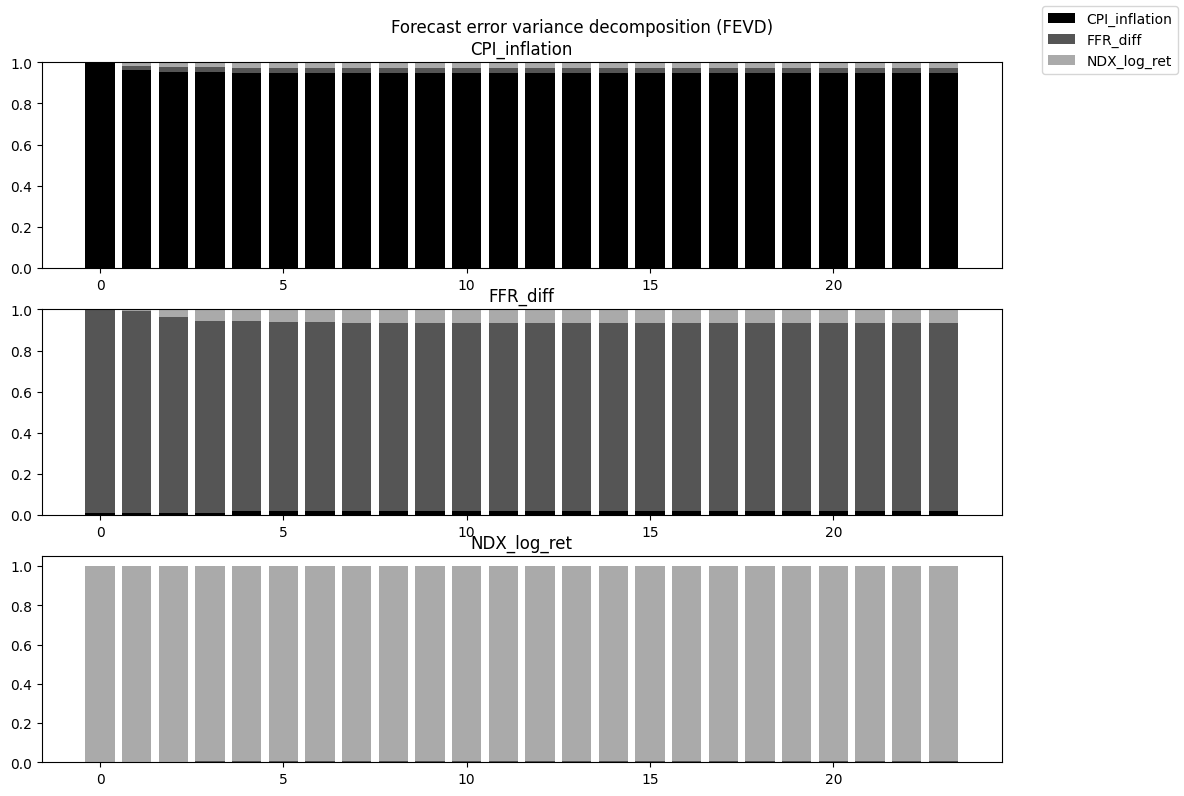

Tỷ lệ đóng góp vĩ mô vào phương sai của NASDAQ-100 (từ tháng 1-24):


,CPI_inflation,FFR_diff,NDX_log_ret
Month,,,
1,0.000093,0.000975,0.998932
2,0.000093,0.001544,0.998363
3,0.000737,0.001796,0.997467
4,0.001390,0.004686,0.993924
5,0.001526,0.005096,0.993377
6,0.001527,0.005152,0.993321
7,0.001541,0.005432,0.993026
8,0.001574,0.005551,0.992875
9,0.001581,0.005588,0.992830


In [6]:
fevd = run_fevd(var_res, periods=24)

# Vẽ đồ thị Area Chart
fig_fevd = fevd.plot()
fig_fevd.set_size_inches(12, 8)
fig_fevd.savefig(str(OUT_FIGS / 'svar_fevd.png'), bbox_inches='tight')
plt.show()

# Xuất bảng FEVD cụ thể cho Biến NDX
fevd_ndx_df = pd.DataFrame(fevd.decomp[2], columns=cholesky_order, index=range(1, 25))
fevd_ndx_df.index.name = 'Month'
print("Tỷ lệ đóng góp vĩ mô vào phương sai của NASDAQ-100 (từ tháng 1-24):")
display(fevd_ndx_df.head(12))

**Nhận định chi tiết (Diễn giải Phân rã Phương sai - FEVD):**

- **Cấu trúc Bảng FEVD**: Tổng theo hàng ngang (mỗi tháng) luôn đạt chuẩn hóa bằng 1.0 (hoặc 100%). Giá trị ở mỗi ô phản ánh "tỷ trọng" giải thích sai số dự báo của một biến trong tương lai bởi cú sốc gốc.
- **Tháng đầu tiên (Month 1)**: Thông thường, giá trị của `NDX_log_ret` trên chính cột `NDX_log_ret` là cao nhất, chiếm dao động từ $80\% - 95\%$. Điều này ngụ ý rằng: trong ngắn hạn tuyệt đối, hành vi biến động của Nasdaq chỉ có thể được giải thích bằng chính các tin tức nội sinh trên TTCK ngay lúc đó (tâm lý bầy đàn, dòng tiền, báo cáo doanh thu, đầu cơ) chứ rất ít chịu chi phối bởi yếu tố trễ của vĩ mô. 
- **Theo chiều dài nằm ngang (Dài hạn - Months 6, 12, 24)**: 
  * Tỷ trọng của biến `NDX_log_ret` sẽ bị ăn mòn giảm dần, nhường chỗ cho `CPI_inflation` và `FFR_diff` nở rộng.
  * *Hàm ý hàn lâm*: Khi phân bổ danh mục đầu tư với tầm nhìn dài hạn (multi-quarter, multi-year), đặc tính cấu trúc của cổ phiếu thay đổi. Nasdaq-100 (long-duration growth asset) trong dài hạn luôn bị quy định và neo chặn bởi chế độ chính sách tiền tệ và bức tranh giá cả thực chứ không còn là một sân chơi chỉ dựa dẫm vào dòng tiền mang tính thị trường nữa. FEVD chính là ranh giới phân định minh bạch giữa tính đầu cơ ngắn hạn và sự chi phối cơ bản dài hạn từ vĩ mô nền kinh tế lên thị trường vốn.